In [1]:
import os
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import SimpleITK as sitk
import matplotlib.pyplot as plt

In [2]:
DATA_ROOT = Path.cwd()

annotations_path = DATA_ROOT / "annotations.csv"
if not annotations_path.exists():
    raise FileNotFoundError(f"annotations.csv not found at: {annotations_path}")

annotations_df = pd.read_csv(annotations_path)

print("DATA_ROOT:", DATA_ROOT)
print("Annotations shape:", annotations_df.shape)
print(annotations_df.head())

DATA_ROOT: c:\Msc 2 DSAI\Medical Images\Re-Identificiation and Growth... Implementation
Annotations shape: (1186, 5)
                                           seriesuid      coordX      coordY  \
0  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222... -128.699421 -175.319272   
1  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  103.783651 -211.925149   
2  1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...   69.639017 -140.944586   
3  1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...  -24.013824  192.102405   
4  1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...    2.441547  172.464881   

       coordZ  diameter_mm  
0 -298.387506     5.651471  
1 -227.121250     4.224708  
2  876.374496     5.786348  
3 -391.081276     8.143262  
4 -405.493732    18.545150  


In [3]:
mhd_paths = []
for subset_name in ["subset0", "subset1"]:
    subset_path = DATA_ROOT / subset_name
    if subset_path.exists():
        mhd_paths.extend(glob.glob(str(subset_path / "*.mhd")))

mhd_paths = sorted(list(dict.fromkeys(mhd_paths)))  # deduplicate + sort

if not mhd_paths:
    raise FileNotFoundError(
        "No .mhd files found in subset0/ or subset1/. "
        f"Checked under: {DATA_ROOT}"
    )

print("Total CT scans found:", len(mhd_paths))
print("First 5 scan paths:")
for p in mhd_paths[:5]:
    print(p)

Total CT scans found: 178
First 5 scan paths:
c:\Msc 2 DSAI\Medical Images\Re-Identificiation and Growth... Implementation\subset0\1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260.mhd
c:\Msc 2 DSAI\Medical Images\Re-Identificiation and Growth... Implementation\subset0\1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492.mhd
c:\Msc 2 DSAI\Medical Images\Re-Identificiation and Growth... Implementation\subset0\1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524522225658609808059.mhd
c:\Msc 2 DSAI\Medical Images\Re-Identificiation and Growth... Implementation\subset0\1.3.6.1.4.1.14519.5.2.1.6279.6001.111172165674661221381920536987.mhd
c:\Msc 2 DSAI\Medical Images\Re-Identificiation and Growth... Implementation\subset0\1.3.6.1.4.1.14519.5.2.1.6279.6001.122763913896761494371822656720.mhd


In [4]:
scan_path_map = {}
for p in mhd_paths:
    seriesuid = Path(p).stem
    scan_path_map[seriesuid] = p

matched_annotations = annotations_df["seriesuid"].isin(scan_path_map.keys()).sum()

print("Mapped scans:", len(scan_path_map))
print("Matched annotations:", matched_annotations, "/", len(annotations_df))

Mapped scans: 178
Matched annotations: 240 / 1186


In [5]:
def load_scan_mhd(mhd_path):
    """
    Load a CT scan in MetaImage format.

    Returns:
        volume_zyx: numpy array of shape [Z, Y, X]
        origin_xyz: numpy array [x, y, z]
        spacing_xyz: numpy array [x, y, z]
    """
    itk_img = sitk.ReadImage(mhd_path)
    volume_zyx = sitk.GetArrayFromImage(itk_img)   # z, y, x
    origin_xyz = np.array(itk_img.GetOrigin(), dtype=np.float32)
    spacing_xyz = np.array(itk_img.GetSpacing(), dtype=np.float32)
    return volume_zyx, origin_xyz, spacing_xyz


def inspect_volume_stats(volume, name="volume"):
    print(f"{name} shape: {volume.shape}")
    print(f"{name} dtype: {volume.dtype}")
    print(f"{name} min: {volume.min()}")
    print(f"{name} max: {volume.max()}")
    print(f"{name} mean: {volume.mean():.3f}")
    print(f"{name} std: {volume.std():.3f}")


def world_to_voxel(world_xyz, origin_xyz, spacing_xyz):
    """
    Convert world coordinates [x, y, z] in mm
    to voxel coordinates [z, y, x] for numpy indexing.
    """
    voxel_xyz = (world_xyz - origin_xyz) / spacing_xyz
    voxel_zyx = np.array([voxel_xyz[2], voxel_xyz[1], voxel_xyz[0]])
    return np.round(voxel_zyx).astype(int)


def normalize_hu(volume, hu_min=-1000, hu_max=600):
    """
    Clip HU values and normalize to [0, 1].
    """
    volume = np.clip(volume, hu_min, hu_max)
    volume = (volume - hu_min) / (hu_max - hu_min)
    return volume.astype(np.float32)


# def extract_patch(volume, center_zyx, patch_size=32):
#     """
#     Extract a cubic 3D patch centered at center_zyx.
#     Pads with zeros if the patch crosses image boundaries.
#     """
#     half = patch_size // 2
#     z, y, x = center_zyx

#     z1, z2 = z - half, z + half
#     y1, y2 = y - half, y + half
#     x1, x2 = x - half, x + half

#     patch = np.zeros((patch_size, patch_size, patch_size), dtype=volume.dtype)

#     vz1, vz2 = max(z1, 0), min(z2, volume.shape[0])
#     vy1, vy2 = max(y1, 0), min(y2, volume.shape[1])
#     vx1, vx2 = max(x1, 0), min(x2, volume.shape[2])

#     pz1 = vz1 - z1
#     py1 = vy1 - y1
#     px1 = vx1 - x1

#     pz2 = pz1 + (vz2 - vz1)
#     py2 = py1 + (vy2 - vy1)
#     px2 = px1 + (vx2 - vx1)

#     patch[pz1:pz2, py1:py2, px1:px2] = volume[vz1:vz2, vy1:vy2, vx1:vx2]
#     return patch

def extract_patch_safe(volume, center_zyx, patch_size=32):
    """
    Extract a cubic 3D patch centered at center_zyx.
    Returns None if the requested patch has no valid overlap.
    """
    half = patch_size // 2
    z, y, x = map(int, center_zyx)

    z1, z2 = z - half, z + half
    y1, y2 = y - half, y + half
    x1, x2 = x - half, x + half

    vz1, vz2 = max(z1, 0), min(z2, volume.shape[0])
    vy1, vy2 = max(y1, 0), min(y2, volume.shape[1])
    vx1, vx2 = max(x1, 0), min(x2, volume.shape[2])

    if vz1 >= vz2 or vy1 >= vy2 or vx1 >= vx2:
        return None

    patch = np.zeros((patch_size, patch_size, patch_size), dtype=volume.dtype)

    pz1 = vz1 - z1
    py1 = vy1 - y1
    px1 = vx1 - x1

    pz2 = pz1 + (vz2 - vz1)
    py2 = py1 + (vy2 - vy1)
    px2 = px1 + (vx2 - vx1)

    if not (0 <= pz1 < patch_size and 0 <= py1 < patch_size and 0 <= px1 < patch_size):
        return None
    if not (0 < pz2 <= patch_size and 0 < py2 <= patch_size and 0 < px2 <= patch_size):
        return None

    patch[pz1:pz2, py1:py2, px1:px2] = volume[vz1:vz2, vy1:vy2, vx1:vx2]
    return patch

In [6]:
matched_df = annotations_df[annotations_df["seriesuid"].isin(scan_path_map.keys())].reset_index(drop=True)

if matched_df.empty:
    raise RuntimeError("No annotations matched the scans in subset0/subset1.")

print("Matched annotation rows:", len(matched_df))
print(matched_df.head())

row = matched_df.iloc[0]
print("\nSelected annotation:")
print(row)

Matched annotation rows: 240
                                           seriesuid      coordX      coordY  \
0  1.3.6.1.4.1.14519.5.2.1.6279.6001.104562737760... -124.834262  127.247155   
1  1.3.6.1.4.1.14519.5.2.1.6279.6001.106719103982...  -57.087180   74.259266   
2  1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896... -100.567944   67.260517   
3  1.3.6.1.4.1.14519.5.2.1.6279.6001.108231420525...   42.574154   90.267552   
4  1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524...   46.188539   48.402806   

        coordZ  diameter_mm  
0  -473.064479    10.465854  
1  1790.494057    13.693566  
2  -231.816619     6.440879  
3   -84.811060     5.916174  
4  -108.578632    13.596471  

Selected annotation:
seriesuid      1.3.6.1.4.1.14519.5.2.1.6279.6001.104562737760...
coordX                                               -124.834262
coordY                                                127.247155
coordZ                                               -473.064479
diameter_mm                 

In [7]:
seriesuid = row["seriesuid"]
scan_path = scan_path_map[seriesuid]

volume, origin_xyz, spacing_xyz = load_scan_mhd(scan_path)

print("Selected seriesuid:", seriesuid)
print("Scan path:", scan_path)
print("Origin [x, y, z]:", origin_xyz)
print("Spacing [x, y, z]:", spacing_xyz)

inspect_volume_stats(volume, "CT volume")

Selected seriesuid: 1.3.6.1.4.1.14519.5.2.1.6279.6001.104562737760173137525888934217
Scan path: c:\Msc 2 DSAI\Medical Images\Re-Identificiation and Growth... Implementation\subset1\1.3.6.1.4.1.14519.5.2.1.6279.6001.104562737760173137525888934217.mhd
Origin [x, y, z]: [-222.5  -87.5 -576.7]
Spacing [x, y, z]: [0.8300781 0.8300781 1.       ]
CT volume shape: (280, 512, 512)
CT volume dtype: int16
CT volume min: -1000
CT volume max: 3000
CT volume mean: -567.391
CT volume std: 502.217


In [9]:
world_xyz = np.array([row["coordX"], row["coordY"], row["coordZ"]], dtype=np.float32)
diameter_mm = float(row["diameter_mm"])

center_zyx = world_to_voxel(world_xyz, origin_xyz, spacing_xyz)

print("World coord [x, y, z]:", world_xyz)
print("Voxel center [z, y, x]:", center_zyx)
print("Diameter (mm):", diameter_mm)

volume_norm = normalize_hu(volume)
patch = extract_patch_safe(volume_norm, center_zyx, patch_size=32)

print("Patch shape:", patch.shape)
print("Patch min:", patch.min())
print("Patch max:", patch.max())
print("Patch mean:", patch.mean())
print("Patch std:", patch.std())

World coord [x, y, z]: [-124.83426   127.247154 -473.06448 ]
Voxel center [z, y, x]: [104 259 118]
Diameter (mm): 10.46585391
Patch shape: (32, 32, 32)
Patch min: 0.0
Patch max: 1.0
Patch mean: 0.25004366
Patch std: 0.2028273


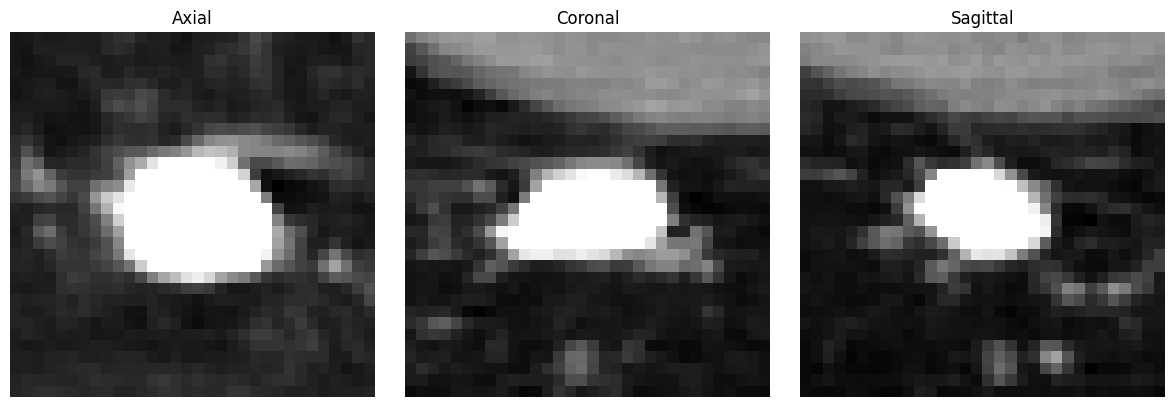

In [10]:
def show_patch_slices(patch):
    mid = patch.shape[0] // 2

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(patch[mid, :, :], cmap="gray")
    axes[0].set_title("Axial")
    axes[0].axis("off")

    axes[1].imshow(patch[:, mid, :], cmap="gray")
    axes[1].set_title("Coronal")
    axes[1].axis("off")

    axes[2].imshow(patch[:, :, mid], cmap="gray")
    axes[2].set_title("Sagittal")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

show_patch_slices(patch)

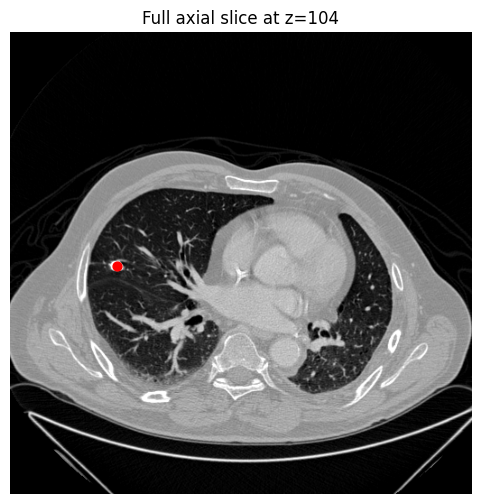

In [11]:
def show_nodule_on_full_slice(volume_norm, center_zyx):
    z, y, x = center_zyx

    plt.figure(figsize=(6, 6))
    plt.imshow(volume_norm[z], cmap="gray")
    plt.scatter(x, y, c="red", s=40)
    plt.title(f"Full axial slice at z={z}")
    plt.axis("off")
    plt.show()

show_nodule_on_full_slice(volume_norm, center_zyx)

In [ ]:
# from scipy.ndimage import zoom

# def resample_volume_to_isotropic(volume_zyx, spacing_xyz, new_spacing_xyz=(1.0, 1.0, 1.0)):
#     """
#     Resample a CT volume from original spacing to isotropic spacing.

#     Args:
#         volume_zyx: numpy array [Z, Y, X]
#         spacing_xyz: original spacing [x, y, z]
#         new_spacing_xyz: target spacing [x, y, z]

#     Returns:
#         resampled_volume_zyx
#         updated_spacing_xyz
#         resize_factor_zyx
#     """
#     spacing_zyx = np.array([spacing_xyz[2], spacing_xyz[1], spacing_xyz[0]], dtype=np.float32)
#     new_spacing_zyx = np.array([new_spacing_xyz[2], new_spacing_xyz[1], new_spacing_xyz[0]], dtype=np.float32)

#     resize_factor_zyx = spacing_zyx / new_spacing_zyx
#     new_shape = np.round(np.array(volume_zyx.shape) * resize_factor_zyx).astype(int)
#     real_resize_factor_zyx = new_shape / np.array(volume_zyx.shape)

#     resampled = zoom(volume_zyx, real_resize_factor_zyx, order=1)  # linear interpolation
#     return resampled, np.array(new_spacing_xyz, dtype=np.float32), real_resize_factor_zyx

In [15]:
from scipy.ndimage import zoom

def resample_volume_to_isotropic(
    volume_zyx,
    spacing_xyz,
    target_spacing_xyz=(1.0, 1.0, 1.0),
    new_spacing_xyz=None,
):
    """
    Resample a CT volume to near-isotropic spacing.

    Args:
        volume_zyx: numpy array [Z, Y, X]
        spacing_xyz: original spacing [x, y, z]
        target_spacing_xyz: desired spacing [x, y, z]
        new_spacing_xyz: backward-compatible alias for target_spacing_xyz

    Returns:
        resampled_volume_zyx
        actual_spacing_xyz
        real_resize_factor_zyx
    """
    if new_spacing_xyz is not None:
        target_spacing_xyz = new_spacing_xyz

    spacing_zyx = np.array([spacing_xyz[2], spacing_xyz[1], spacing_xyz[0]], dtype=np.float32)
    target_spacing_zyx = np.array(
        [target_spacing_xyz[2], target_spacing_xyz[1], target_spacing_xyz[0]],
        dtype=np.float32
    )

    old_shape = np.array(volume_zyx.shape, dtype=np.float32)

    resize_factor_zyx = spacing_zyx / target_spacing_zyx
    new_shape = np.round(old_shape * resize_factor_zyx).astype(int)

    real_resize_factor_zyx = new_shape / old_shape
    actual_spacing_zyx = spacing_zyx / real_resize_factor_zyx

    resampled = zoom(volume_zyx, real_resize_factor_zyx, order=1)

    actual_spacing_xyz = np.array(
        [actual_spacing_zyx[2], actual_spacing_zyx[1], actual_spacing_zyx[0]],
        dtype=np.float32
    )

    return resampled, actual_spacing_xyz, real_resize_factor_zyx

In [13]:
def world_to_voxel_zyx(world_xyz, origin_xyz, spacing_xyz):
    """
    Convert world coordinates [x, y, z] to voxel coordinates [z, y, x].
    """
    voxel_xyz = (world_xyz - origin_xyz) / spacing_xyz
    voxel_zyx = np.array([voxel_xyz[2], voxel_xyz[1], voxel_xyz[0]])
    return np.round(voxel_zyx).astype(int)

In [16]:
# Use the same previously selected row and scan
seriesuid = row["seriesuid"]
scan_path = scan_path_map[seriesuid]

volume, origin_xyz, spacing_xyz = load_scan_mhd(scan_path)

print("Original shape:", volume.shape)
print("Original spacing [x,y,z]:", spacing_xyz)

volume_resampled, spacing_xyz_resampled, resize_factor_zyx = resample_volume_to_isotropic(
    volume, spacing_xyz, new_spacing_xyz=(1.0, 1.0, 1.0)
)

print("Resampled shape:", volume_resampled.shape)
print("Resampled spacing [x,y,z]:", spacing_xyz_resampled)
print("Resize factor [z,y,x]:", resize_factor_zyx)

inspect_volume_stats(volume_resampled, "resampled_CT_volume")

Original shape: (280, 512, 512)
Original spacing [x,y,z]: [0.8300781 0.8300781 1.       ]
Resampled shape: (280, 425, 425)
Resampled spacing [x,y,z]: [1. 1. 1.]
Resize factor [z,y,x]: [1.         0.83007812 0.83007812]
resampled_CT_volume shape: (280, 425, 425)
resampled_CT_volume dtype: int16
resampled_CT_volume min: -1000
resampled_CT_volume max: 3000
resampled_CT_volume mean: -567.695
resampled_CT_volume std: 499.564


In [18]:
world_xyz = np.array([row["coordX"], row["coordY"], row["coordZ"]], dtype=np.float32)
diameter_mm = float(row["diameter_mm"])

center_zyx_resampled = world_to_voxel_zyx(world_xyz, origin_xyz, spacing_xyz_resampled)

print("World coord [x,y,z]:", world_xyz)
print("Resampled voxel center [z,y,x]:", center_zyx_resampled)
print("Diameter (mm):", diameter_mm)

volume_resampled_norm = normalize_hu(volume_resampled)
patch_resampled = extract_patch_safe(volume_resampled_norm, center_zyx_resampled, patch_size=32)

if patch_resampled is None:
    raise RuntimeError("Failed to extract resampled patch: patch is out of bounds.")

print("Resampled patch shape:", patch_resampled.shape)
print("Resampled patch min:", patch_resampled.min())
print("Resampled patch max:", patch_resampled.max())
print("Resampled patch mean:", patch_resampled.mean())
print("Resampled patch std:", patch_resampled.std())

World coord [x,y,z]: [-124.83426   127.247154 -473.06448 ]
Resampled voxel center [z,y,x]: [104 215  98]
Diameter (mm): 10.46585391
Resampled patch shape: (32, 32, 32)
Resampled patch min: 0.0
Resampled patch max: 1.0
Resampled patch mean: 0.2321474
Resampled patch std: 0.18707463


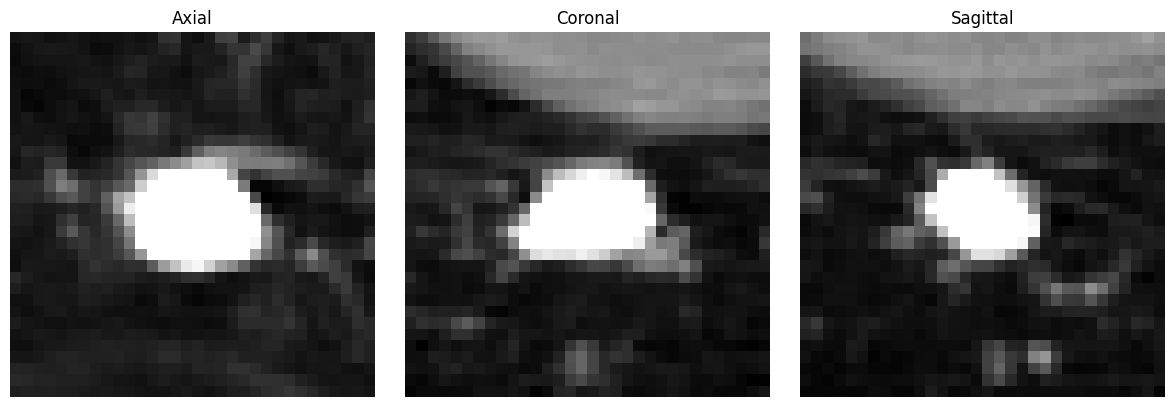

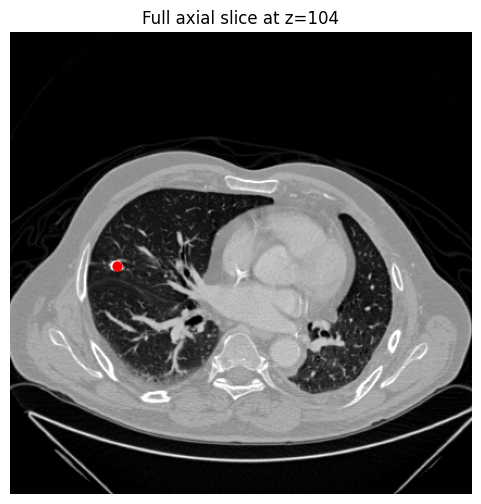

In [19]:
show_patch_slices(patch_resampled)
show_nodule_on_full_slice(volume_resampled_norm, center_zyx_resampled)

In [ ]:
# PATCH_SIZE = 32

# nodule_records = []

# matched_df = annotations_df[annotations_df["seriesuid"].isin(scan_path_map.keys())].reset_index(drop=True)

# for i, ann in matched_df.iterrows():
#     seriesuid = ann["seriesuid"]
#     scan_path = scan_path_map[seriesuid]

#     try:
#         volume, origin_xyz, spacing_xyz = load_scan_mhd(scan_path)
#         volume_resampled, spacing_xyz_resampled, _ = resample_volume_to_isotropic(
#             volume, spacing_xyz, new_spacing_xyz=(1.0, 1.0, 1.0)
#         )
#         volume_resampled_norm = normalize_hu(volume_resampled)

#         world_xyz = np.array([ann["coordX"], ann["coordY"], ann["coordZ"]], dtype=np.float32)
#         center_zyx = world_to_voxel_zyx(world_xyz, origin_xyz, spacing_xyz_resampled)

#         patch = extract_patch(volume_resampled_norm, center_zyx, patch_size=PATCH_SIZE)

#         nodule_records.append({
#             "seriesuid": seriesuid,
#             "coordX": float(ann["coordX"]),
#             "coordY": float(ann["coordY"]),
#             "coordZ": float(ann["coordZ"]),
#             "diameter_mm": float(ann["diameter_mm"]),
#             "center_z": int(center_zyx[0]),
#             "center_y": int(center_zyx[1]),
#             "center_x": int(center_zyx[2]),
#             "patch": patch
#         })

#     except Exception as e:
#         print(f"[Warning] Failed on index {i}, seriesuid={seriesuid}: {e}")

# print("Total extracted nodules:", len(nodule_records))

In [20]:
PATCH_SIZE = 32

nodule_records = []
skipped_records = []

matched_df = annotations_df[annotations_df["seriesuid"].isin(scan_path_map.keys())].reset_index(drop=True)

for i, ann in matched_df.iterrows():
    seriesuid = ann["seriesuid"]
    scan_path = scan_path_map[seriesuid]

    try:
        volume, origin_xyz, spacing_xyz = load_scan_mhd(scan_path)

        volume_resampled, actual_spacing_xyz, _ = resample_volume_to_isotropic(
            volume, spacing_xyz, target_spacing_xyz=(1.0, 1.0, 1.0)
        )

        volume_resampled_norm = normalize_hu(volume_resampled)

        world_xyz = np.array([ann["coordX"], ann["coordY"], ann["coordZ"]], dtype=np.float32)
        center_zyx = world_to_voxel(world_xyz, origin_xyz, actual_spacing_xyz)

        patch = extract_patch_safe(volume_resampled_norm, center_zyx, patch_size=PATCH_SIZE)

        if patch is None:
            skipped_records.append({
                "index": i,
                "seriesuid": seriesuid,
                "reason": "invalid_or_out_of_bounds_patch"
            })
            continue

        nodule_records.append({
            "seriesuid": seriesuid,
            "coordX": float(ann["coordX"]),
            "coordY": float(ann["coordY"]),
            "coordZ": float(ann["coordZ"]),
            "diameter_mm": float(ann["diameter_mm"]),
            "center_z": int(center_zyx[0]),
            "center_y": int(center_zyx[1]),
            "center_x": int(center_zyx[2]),
            "patch": patch
        })

    except Exception as e:
        skipped_records.append({
            "index": i,
            "seriesuid": seriesuid,
            "reason": str(e)
        })

print("Total matched annotations:", len(matched_df))
print("Successfully extracted nodules:", len(nodule_records))
print("Skipped nodules:", len(skipped_records))

Total matched annotations: 240
Successfully extracted nodules: 238
Skipped nodules: 2


In [ ]:
# nodule_df = pd.DataFrame([
#     {
#         "seriesuid": r["seriesuid"],
#         "coordX": r["coordX"],
#         "coordY": r["coordY"],
#         "coordZ": r["coordZ"],
#         "diameter_mm": r["diameter_mm"],
#         "center_z": r["center_z"],
#         "center_y": r["center_y"],
#         "center_x": r["center_x"],
#     }
#     for r in nodule_records
# ])

# print(nodule_df.shape)
# print(nodule_df.head())
# print(nodule_df["diameter_mm"].describe())

In [21]:
nodule_df = pd.DataFrame([
    {
        "seriesuid": r["seriesuid"],
        "coordX": r["coordX"],
        "coordY": r["coordY"],
        "coordZ": r["coordZ"],
        "diameter_mm": r["diameter_mm"],
        "center_z": r["center_z"],
        "center_y": r["center_y"],
        "center_x": r["center_x"],
    }
    for r in nodule_records
])

print(nodule_df.shape)
print(nodule_df.head())
print(nodule_df["diameter_mm"].describe())

(238, 8)
                                           seriesuid      coordX      coordY  \
0  1.3.6.1.4.1.14519.5.2.1.6279.6001.104562737760... -124.834262  127.247155   
1  1.3.6.1.4.1.14519.5.2.1.6279.6001.106719103982...  -57.087180   74.259266   
2  1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896... -100.567944   67.260517   
3  1.3.6.1.4.1.14519.5.2.1.6279.6001.108231420525...   42.574154   90.267552   
4  1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524...   46.188539   48.402806   

        coordZ  diameter_mm  center_z  center_y  center_x  
0  -473.064479    10.465854       104       215        98  
1  1790.494057    13.693566       186       216       106  
2  -231.816619     6.440879        82       257        82  
3   -84.811060     5.916174       203       246       228  
4  -108.578632    13.596471        85       157       234  
count    238.000000
mean       8.402292
std        4.513568
min        3.439487
25%        5.252075
50%        6.908865
75%        9.714285
max       

Random sample index: 217
SeriesUID: 1.3.6.1.4.1.14519.5.2.1.6279.6001.756684168227383088294595834066
Diameter: 3.986088287


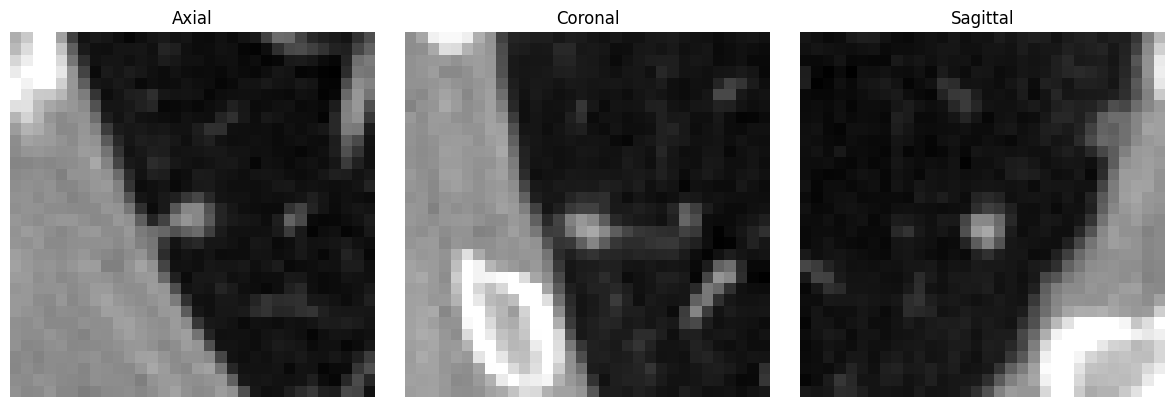

In [22]:
import random

idx = random.randint(0, len(nodule_records) - 1)
sample_patch = nodule_records[idx]["patch"]

print("Random sample index:", idx)
print("SeriesUID:", nodule_records[idx]["seriesuid"])
print("Diameter:", nodule_records[idx]["diameter_mm"])

show_patch_slices(sample_patch)

In [23]:
import random
import torch
from torch.utils.data import Dataset

def augment_patch(patch):
    """
    Very light augmentation to simulate pseudo-follow-up variation.
    """
    aug = patch.copy()

    # random flips
    if random.random() < 0.5:
        aug = np.flip(aug, axis=0).copy()
    if random.random() < 0.5:
        aug = np.flip(aug, axis=1).copy()
    if random.random() < 0.5:
        aug = np.flip(aug, axis=2).copy()

    # small gaussian noise
    if random.random() < 0.7:
        noise = np.random.normal(0, 0.01, size=aug.shape).astype(np.float32)
        aug = aug + noise

    aug = np.clip(aug, 0.0, 1.0)
    return aug.astype(np.float32)


class NodulePairDataset(Dataset):
    def __init__(self, nodule_records, num_pairs=2000):
        self.nodule_records = nodule_records
        self.num_pairs = num_pairs

    def __len__(self):
        return self.num_pairs

    def __getitem__(self, idx):
        label = np.random.randint(0, 2)

        if label == 1:
            # positive pair: same nodule + augmented copy
            rec = random.choice(self.nodule_records)
            patch1 = rec["patch"].astype(np.float32)
            patch2 = augment_patch(rec["patch"])
        else:
            # negative pair: two different nodules
            rec1, rec2 = random.sample(self.nodule_records, 2)
            patch1 = rec1["patch"].astype(np.float32)
            patch2 = rec2["patch"].astype(np.float32)

        patch1 = torch.tensor(patch1[None, ...], dtype=torch.float32)  # [1, D, H, W]
        patch2 = torch.tensor(patch2[None, ...], dtype=torch.float32)
        label = torch.tensor([label], dtype=torch.float32)

        return patch1, patch2, label

In [ ]:
# import random

# random.seed(42)
# np.random.seed(42)
# torch.manual_seed(42)

# all_indices = list(range(len(nodule_records)))
# random.shuffle(all_indices)

# split_idx = int(0.8 * len(all_indices))
# train_indices = all_indices[:split_idx]
# val_indices = all_indices[split_idx:]

# train_nodules = [nodule_records[i] for i in train_indices]
# val_nodules = [nodule_records[i] for i in val_indices]

# print("Train nodules:", len(train_nodules))
# print("Val nodules:", len(val_nodules))

Train nodules: 190
Val nodules: 48


In [44]:
import random
from collections import defaultdict

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Group nodules by scan
series_to_records = defaultdict(list)
for rec in nodule_records:
    series_to_records[rec["seriesuid"]].append(rec)

all_series = list(series_to_records.keys())
random.shuffle(all_series)

split_idx = int(0.8 * len(all_series))
train_series = set(all_series[:split_idx])
val_series = set(all_series[split_idx:])

train_nodules = [rec for rec in nodule_records if rec["seriesuid"] in train_series]
val_nodules   = [rec for rec in nodule_records if rec["seriesuid"] in val_series]

print("Train series:", len(train_series))
print("Val series:", len(val_series))
print("Train nodules:", len(train_nodules))
print("Val nodules:", len(val_nodules))

Train series: 100
Val series: 26
Train nodules: 184
Val nodules: 54


In [ ]:
# from torch.utils.data import DataLoader

# train_dataset = NodulePairDataset(train_nodules, num_pairs=3000)
# val_dataset = NodulePairDataset(val_nodules, num_pairs=800)

# train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
# val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)

# # Quick sanity check
# x1, x2, y = next(iter(train_loader))
# print("x1:", x1.shape)   # [B, 1, 32, 32, 32]
# print("x2:", x2.shape)
# print("y :", y.shape)

x1: torch.Size([8, 1, 32, 32, 32])
x2: torch.Size([8, 1, 32, 32, 32])
y : torch.Size([8, 1])


In [60]:
import random
import torch
from torch.utils.data import Dataset

def augment_patch(patch):
    aug = patch.copy()

    if random.random() < 0.5:
        aug = np.flip(aug, axis=0).copy()
    if random.random() < 0.5:
        aug = np.flip(aug, axis=1).copy()
    if random.random() < 0.5:
        aug = np.flip(aug, axis=2).copy()

    if random.random() < 0.7:
        noise = np.random.normal(0, 0.01, size=aug.shape).astype(np.float32)
        aug = aug + noise

    aug = np.clip(aug, 0.0, 1.0)
    return aug.astype(np.float32)


def deterministic_augment_patch(patch, seed=0):
    rng = np.random.RandomState(seed)
    aug = patch.copy()

    if rng.rand() < 0.5:
        aug = np.flip(aug, axis=0).copy()
    if rng.rand() < 0.5:
        aug = np.flip(aug, axis=1).copy()
    if rng.rand() < 0.5:
        aug = np.flip(aug, axis=2).copy()

    noise = rng.normal(0, 0.01, size=aug.shape).astype(np.float32)
    aug = aug + noise

    aug = np.clip(aug, 0.0, 1.0)
    return aug.astype(np.float32)


def sample_hard_negative_pair(nodule_records, diameter_tolerance=2.0):
    rec1 = random.choice(nodule_records)
    d1 = rec1["diameter_mm"]

    candidates = [
        rec for rec in nodule_records
        if rec is not rec1 and abs(rec["diameter_mm"] - d1) <= diameter_tolerance
    ]

    if len(candidates) > 0:
        rec2 = random.choice(candidates)
    else:
        rec2 = random.choice([rec for rec in nodule_records if rec is not rec1])

    return rec1, rec2


class FixedNodulePairDataset(Dataset):
    def __init__(self, nodule_records, num_pairs=1000, training=True):
        self.nodule_records = nodule_records
        self.num_pairs = num_pairs
        self.training = training
        self.pairs = self._build_pairs()

    def _build_pairs(self):
        pairs = []
        n = len(self.nodule_records)

        for pair_idx in range(self.num_pairs):
            label = np.random.randint(0, 2)

            if label == 1:
                rec = random.choice(self.nodule_records)
                patch1 = rec["patch"].astype(np.float32)

                if self.training:
                    patch2 = augment_patch(rec["patch"])
                else:
                    patch2 = deterministic_augment_patch(rec["patch"], seed=pair_idx)

            else:
                rec1, rec2 = sample_hard_negative_pair(self.nodule_records, diameter_tolerance=2.0)
                patch1 = rec1["patch"].astype(np.float32)
                patch2 = rec2["patch"].astype(np.float32)

            pairs.append((patch1, patch2, float(label)))

        return pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        patch1, patch2, label = self.pairs[idx]

        patch1 = torch.tensor(patch1[None, ...], dtype=torch.float32)
        patch2 = torch.tensor(patch2[None, ...], dtype=torch.float32)
        label = torch.tensor([label], dtype=torch.float32)

        return patch1, patch2, label

In [61]:
from torch.utils.data import DataLoader

train_dataset = FixedNodulePairDataset(train_nodules, num_pairs=3000, training=True)
val_dataset   = FixedNodulePairDataset(val_nodules,   num_pairs=800,  training=False)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False, num_workers=0)

In [47]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Simple3DEncoder(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv3d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm3d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(2),   # 32 -> 16

            nn.Conv3d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(2),   # 16 -> 8

            nn.Conv3d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(2),   # 8 -> 4

            nn.Conv3d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool3d((2, 2, 2))
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 2 * 2 * 2, embedding_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.fc(x)
        return x


class Siamese3DNet(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()
        self.encoder = Simple3DEncoder(embedding_dim=embedding_dim)

        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x1, x2):
        f1 = self.encoder(x1)
        f2 = self.encoder(x2)

        diff = torch.abs(f1 - f2)
        logits = self.classifier(diff).squeeze(1)   # [B]
        return logits

In [62]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = Siamese3DNet(embedding_dim=128).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Using device: cuda


In [49]:
def compute_accuracy_from_logits(logits, labels):
    probs = torch.sigmoid(logits)
    preds = (probs >= 0.5).float()
    acc = (preds == labels).float().mean().item()
    return acc


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    running_loss = 0.0
    running_acc = 0.0
    total_batches = 0

    for x1, x2, y in loader:
        x1 = x1.to(device)
        x2 = x2.to(device)
        y = y.view(-1).to(device)   # [B]

        optimizer.zero_grad()

        logits = model(x1, x2)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        acc = compute_accuracy_from_logits(logits.detach(), y)

        running_loss += loss.item()
        running_acc += acc
        total_batches += 1

    return running_loss / total_batches, running_acc / total_batches


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_acc = 0.0
    total_batches = 0

    for x1, x2, y in loader:
        x1 = x1.to(device)
        x2 = x2.to(device)
        y = y.view(-1).to(device)

        logits = model(x1, x2)
        loss = criterion(logits, y)
        acc = compute_accuracy_from_logits(logits, y)

        running_loss += loss.item()
        running_acc += acc
        total_batches += 1

    return running_loss / total_batches, running_acc / total_batches

In [ ]:
import copy

num_epochs = 5
history = []
best_val_acc = -1.0
best_epoch = -1
best_model_state = None

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )

print(f"Best validation accuracy: {best_val_acc:.4f} at epoch {best_epoch}")

Epoch 1/5 | Train Loss: 0.6470, Train Acc: 0.6063 | Val Loss: 0.5533, Val Acc: 0.6462
Epoch 2/5 | Train Loss: 0.5630, Train Acc: 0.6940 | Val Loss: 0.4705, Val Acc: 0.7200
Epoch 3/5 | Train Loss: 0.5230, Train Acc: 0.7207 | Val Loss: 0.4870, Val Acc: 0.7175
Epoch 4/5 | Train Loss: 0.4940, Train Acc: 0.7483 | Val Loss: 0.4860, Val Acc: 0.7612
Epoch 5/5 | Train Loss: 0.4679, Train Acc: 0.7707 | Val Loss: 0.4062, Val Acc: 0.8512


In [64]:
history_df = pd.DataFrame(history)
print(history_df)

   epoch  train_loss  train_acc  val_loss  val_acc
0      1    0.647012   0.606333  0.553319  0.64625
1      2    0.562990   0.694000  0.470533  0.72000
2      3    0.523042   0.720667  0.486950  0.71750
3      4    0.494009   0.748333  0.486050  0.76125
4      5    0.467850   0.770667  0.406160  0.85125


In [65]:
@torch.no_grad()
def inspect_batch_predictions(model, loader, device, num_samples=5):
    model.eval()
    x1, x2, y = next(iter(loader))

    x1 = x1.to(device)
    x2 = x2.to(device)

    logits = model(x1, x2)
    probs = torch.sigmoid(logits).cpu().numpy()
    labels = y.view(-1).numpy()

    for i in range(min(num_samples, len(labels))):
        pred = 1 if probs[i] >= 0.5 else 0
        print(f"Sample {i}: prob={probs[i]:.4f}, pred={pred}, true={int(labels[i])}")

inspect_batch_predictions(model, val_loader, device, num_samples=8)

Sample 0: prob=0.4930, pred=0, true=1
Sample 1: prob=0.8381, pred=1, true=1
Sample 2: prob=0.2085, pred=0, true=0
Sample 3: prob=0.0024, pred=0, true=0
Sample 4: prob=0.7425, pred=1, true=0
Sample 5: prob=0.4671, pred=0, true=0
Sample 6: prob=0.1954, pred=0, true=0
Sample 7: prob=0.3713, pred=0, true=0


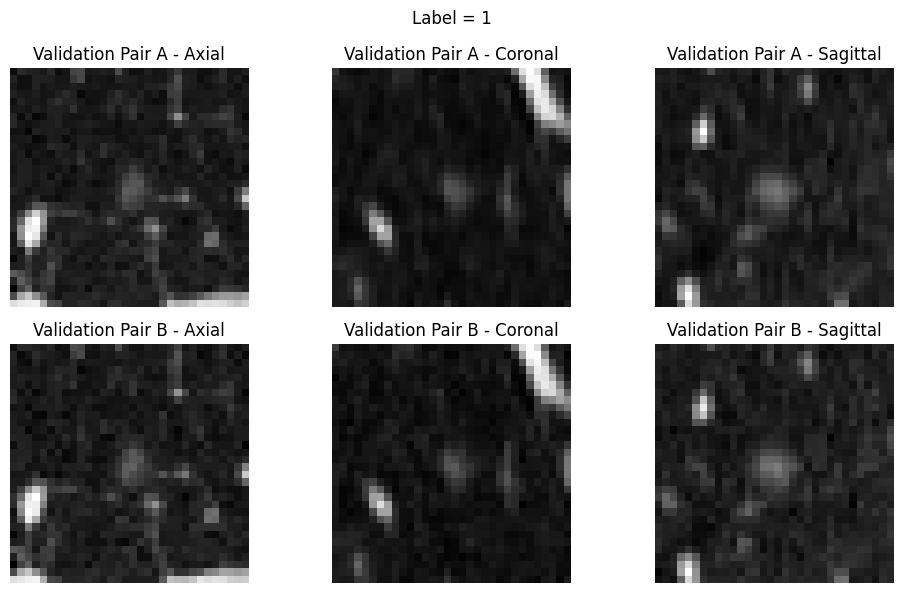

In [58]:
def show_pair(x1, x2, label, title_prefix="Pair"):
    x1 = x1.squeeze().cpu().numpy()
    x2 = x2.squeeze().cpu().numpy()

    mid = x1.shape[0] // 2

    fig, axes = plt.subplots(2, 3, figsize=(10, 6))

    axes[0, 0].imshow(x1[mid], cmap="gray")
    axes[0, 0].set_title(f"{title_prefix} A - Axial")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(x1[:, mid, :], cmap="gray")
    axes[0, 1].set_title(f"{title_prefix} A - Coronal")
    axes[0, 1].axis("off")

    axes[0, 2].imshow(x1[:, :, mid], cmap="gray")
    axes[0, 2].set_title(f"{title_prefix} A - Sagittal")
    axes[0, 2].axis("off")

    axes[1, 0].imshow(x2[mid], cmap="gray")
    axes[1, 0].set_title(f"{title_prefix} B - Axial")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(x2[:, mid, :], cmap="gray")
    axes[1, 1].set_title(f"{title_prefix} B - Coronal")
    axes[1, 1].axis("off")

    axes[1, 2].imshow(x2[:, :, mid], cmap="gray")
    axes[1, 2].set_title(f"{title_prefix} B - Sagittal")
    axes[1, 2].axis("off")

    plt.suptitle(f"Label = {int(label)}")
    plt.tight_layout()
    plt.show()


x1, x2, y = val_dataset[0]
show_pair(x1, x2, y.item(), title_prefix="Validation Pair")

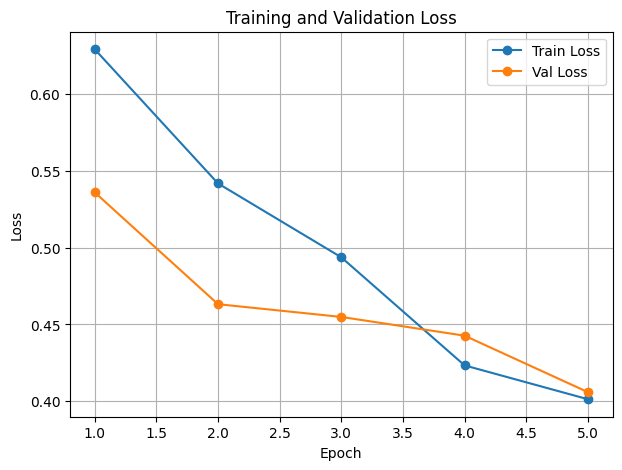

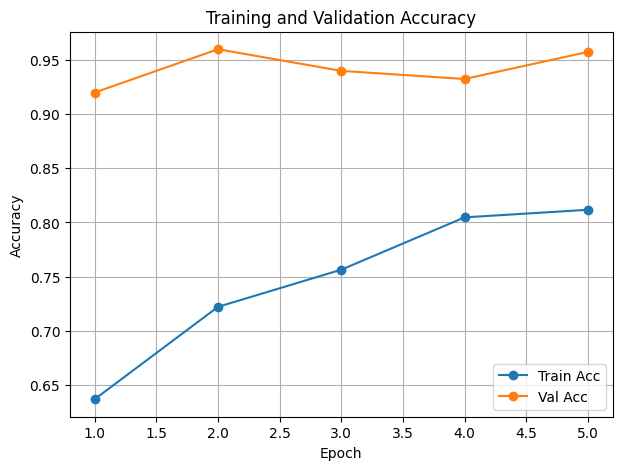

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7,5))
plt.plot(history_df["epoch"], history_df["train_acc"], marker="o", label="Train Acc")
plt.plot(history_df["epoch"], history_df["val_acc"], marker="o", label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
if best_model_state is None:
    raise RuntimeError("No best model state found. Run the training cell first.")

torch.save(best_model_state, "siamese_3d_luna16_series_split.pth")
print("Model saved successfully.")

Model saved.


In [66]:
val_x1_a, val_x2_a, val_y_a = val_dataset[0]
val_x1_b, val_x2_b, val_y_b = val_dataset[0]

print("Validation pair reproducible:", torch.allclose(val_x2_a, val_x2_b))
print("Validation labels reproducible:", torch.equal(val_y_a, val_y_b))

Validation pair reproducible: True
Validation labels reproducible: True


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

@torch.no_grad()
def evaluate_model(model, loader, device):
    model.eval()

    all_probs = []
    all_preds = []
    all_labels = []

    for x1, x2, y in loader:
        x1 = x1.to(device)
        x2 = x2.to(device)
        y = y.view(-1).cpu().numpy()

        logits = model(x1, x2)
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs >= 0.5).astype(int)

        all_probs.extend(probs.tolist())
        all_preds.extend(preds.tolist())
        all_labels.extend(y.astype(int).tolist())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

labels, preds, probs = evaluate_model(model, val_loader, device)

cm = confusion_matrix(labels, preds)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n")
print(classification_report(labels, preds, digits=4))
print("ROC-AUC:", roc_auc_score(labels, probs))

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Validation Confusion Matrix")
plt.show()

plt.figure(figsize=(6, 5))
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(labels, probs)
plt.title("Validation ROC Curve")
plt.grid(True)
plt.show()

evaluation_summary = {
    "roc_auc": float(roc_auc_score(labels, probs)),
    "confusion_matrix": cm.tolist()
}

print("Evaluation summary:", evaluation_summary)

from scipy.ndimage import zoom

def resize_to_shape(volume, target_shape=(32, 32, 32)):
    factors = [t / s for t, s in zip(target_shape, volume.shape)]
    return zoom(volume, factors, order=1)

def scale_nodule_patch(patch, scale=1.1, output_size=32):
    """
    Simulate growth/shrinkage by scaling the whole patch,
    then center-cropping or padding back to 32x32x32.
    """
    scaled = zoom(patch, zoom=scale, order=1)

    out = np.zeros((output_size, output_size, output_size), dtype=np.float32)

    sz, sy, sx = scaled.shape
    oz, oy, ox = output_size, output_size, output_size

    src_z1 = max((sz - oz) // 2, 0)
    src_y1 = max((sy - oy) // 2, 0)
    src_x1 = max((sx - ox) // 2, 0)
    src_z2 = min(src_z1 + oz, sz)
    src_y2 = min(src_y1 + oy, sy)
    src_x2 = min(src_x1 + ox, sx)

    dst_z1 = max((oz - sz) // 2, 0)
    dst_y1 = max((oy - sy) // 2, 0)
    dst_x1 = max((ox - sx) // 2, 0)
    dst_z2 = dst_z1 + (src_z2 - src_z1)
    dst_y2 = dst_y1 + (src_y2 - src_y1)
    dst_x2 = dst_x1 + (src_x2 - src_x1)

    out[dst_z1:dst_z2, dst_y1:dst_y2, dst_x1:dst_x2] = scaled[src_z1:src_z2, src_y1:src_y2, src_x1:src_x2]
    return np.clip(out, 0.0, 1.0)

rec = random.choice(val_nodules)
patch = rec["patch"].astype(np.float32)

patch_small = scale_nodule_patch(patch, scale=0.90)
patch_large = scale_nodule_patch(patch, scale=1.15)

show_pair(
    torch.tensor(patch[None, ...]),
    torch.tensor(patch_large[None, ...]),
    1,
    title_prefix="Synthetic Growth Pair"
 )